# Warmup ablation: four configurations, 5,000 entities, three seeds
This is a new research stage. Your earlier `research_pipeline.ipynb` and its results
remain historical artifacts. Run this notebook from top to bottom on a GPU runtime.
The twelve runs are substantial; they have not been executed during code development.

All KG-specific parameters start from scratch. Only frozen pretrained RoBERTa and
independent frozen text caches are reused. No baseline or earlier-run weights are
transferred. Warmup is 5 structural + 25 integrated updates; no-warmup is 30 integrated
updates. Validation chooses checkpoints and the final configuration; test never selects.


## 1. Environment, repository and GPU setup


In [58]:
import os
import sys
import subprocess
from pathlib import Path

os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
os.environ['PYTHONUNBUFFERED'] = '1'
REPO_URL = 'https://github.com/Rashmika119/Research-project.git'
REPO_REF = 'feature/phase_03'  # Push this stage first; a fixed commit SHA is preferable.
REPO_DIR = Path('/content/Research-project')
if not REPO_DIR.exists():
    subprocess.run(['git', 'clone', REPO_URL, str(REPO_DIR)], check=True)
    subprocess.run(['git', 'checkout', REPO_REF], cwd=REPO_DIR, check=True)
os.chdir(REPO_DIR)
assert Path('run_warmup_ablation.py').is_file(), 'Checkout the commit containing the new warmup study.'
print('Repository SHA:', subprocess.check_output(['git', 'rev-parse', 'HEAD'], text=True).strip())
subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt'], check=True)
import torch
print('Python:', sys.version)
print('PyTorch:', torch.__version__, '; CUDA:', torch.version.cuda)
assert torch.cuda.is_available(), 'Select Runtime > Change runtime type > T4 GPU.'
GPU_NAME = torch.cuda.get_device_name(0)
print('GPU:', GPU_NAME, '; Tesla T4 selected:', 'T4' in GPU_NAME)
if 'T4' not in GPU_NAME:
    print('Using another GPU; keep hardware consistent across all twelve runs.')


Repository SHA: 9a0420d58ce4b815bf0a9805e2fb224da512588f
Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu130 ; CUDA: 13.0
GPU: Tesla T4 ; Tesla T4 selected: True


## 2. Google Drive and verified local model cache


In [59]:
from google.colab import drive
drive.mount('/content/drive')
SHARED_ROOT = Path('/content/drive/MyDrive/Research/scratch_pipeline_v1')
STAGE_ROOT = Path('/content/drive/MyDrive/Research/warmup_ablation_5000')
STAGE_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['HF_HOME'] = '/content/hf_cache'
os.environ['HF_HUB_CACHE'] = '/content/hf_cache/hub'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/content/hf_cache/hub'
os.environ.pop('TRANSFORMERS_CACHE', None)
os.environ['RESEARCH_MODEL_BACKUP'] = str(SHARED_ROOT / 'verified_roberta_backup')
print('Model loads from:', os.environ['HF_HUB_CACHE'])
print('Verified persistent backup:', os.environ['RESEARCH_MODEL_BACKUP'])
print('New experiment root:', STAGE_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loads from: /content/hf_cache/hub
Verified persistent backup: /content/drive/MyDrive/Research/scratch_pipeline_v1/verified_roberta_backup
New experiment root: /content/drive/MyDrive/Research/warmup_ablation_5000


## 3. Four configurations and fixed training budget


In [60]:
import json
import yaml
import pandas as pd
from datetime import datetime
from IPython.display import display, Image
from training.variants import CONFIGURATIONS, configuration_settings
from training.process import run_logged

MAX_ENTITIES = 5000
SEEDS = [0]
TOTAL_EPOCHS = 30
WARMUP_EPOCHS = 5
SUBSET_SEED = 0
RUN_ALL_CONFIGURATIONS = True
SKIP_COMPLETED = True
RESUME_INTERRUPTED = True
RUN_OFFLINE_TESTS = True
RUN_REAL_LM_SMOKE = True
RUN_CUDA_RESUME_CHECK = True
RUN_REAL_LM_RESUME_CHECK = True
TEXT_BATCH_SIZE = 256
EVAL_BATCH_SIZE = 512
MAX_TEXT_LENGTH = 64
RUN_TAG = 'warmup5000_induced_v7_run1'  # Reuse only to resume; change for changed settings/code.

protocol = yaml.safe_load(Path('experiments/configs/research_protocol.yaml').read_text(encoding='utf-8-sig'))
assert list(CONFIGURATIONS) == protocol['study']['configurations']
assert 0 < WARMUP_EPOCHS < TOTAL_EPOCHS and MAX_ENTITIES >= 2
assert SEEDS and len(SEEDS) == len(set(SEEDS))
RUN_ROOT = STAGE_ROOT / RUN_TAG
EXPERIMENT_DIR = RUN_ROOT / 'runs'
MANIFEST = EXPERIMENT_DIR / 'subset_manifest.json'
RAW_DIR = SHARED_ROOT / 'data' / 'fb15k237'
TEXT_DIR = SHARED_ROOT / 'data' / 'text'
POOLED_CACHE = SHARED_ROOT / 'pooled_text_cache'
LOG_DIR = RUN_ROOT / 'logs' / datetime.now().strftime('%Y%m%d_%H%M%S_%f')
RUN_ROOT.mkdir(parents=True, exist_ok=True)
CPU_ENV = dict(os.environ, CUDA_VISIBLE_DEVICES='', HF_HUB_OFFLINE='1')
CPU_ENV.pop('RESEARCH_MODEL_BACKUP', None)  # Corruption fixtures must never touch Drive backups.
PRETRAINED_VERIFIED = False

def ensure_pretrained():
    global PRETRAINED_VERIFIED
    if not PRETRAINED_VERIFIED:
        run_logged([sys.executable, 'run_pretrained_check.py', '--device', 'cuda',
                    '--report', str(LOG_DIR / 'pretrained_report.json')], LOG_DIR / 'pretrained.log')
        PRETRAINED_VERIFIED = True

rows = []
for identifier in CONFIGURATIONS:
    architecture, warm = configuration_settings(identifier, WARMUP_EPOCHS)
    rows.append({'configuration': identifier, 'architecture': architecture,
                 'structural_updates': warm, 'integrated_updates': TOTAL_EPOCHS - warm,
                 'total_updates': TOTAL_EPOCHS, 'seeds': str(SEEDS)})
display(pd.DataFrame(rows))
print('Runs:', len(CONFIGURATIONS) * len(SEEDS), '; LR=0.001; KG width=32; Adam; four negatives; full-subset updates')
print('No-Refinement remains available through the single-run CLI; it is excluded here.')


,configuration,architecture,structural_updates,integrated_updates,total_updates,seeds
0,residual-warmup,residual,5,25,30,[0]
1,residual-no-warmup,residual,0,30,30,[0]
2,residual-no-softprompt-warmup,residual-no-softprompt,5,25,30,[0]
3,residual-no-softprompt-no-warmup,residual-no-softprompt,0,30,30,[0]


Runs: 4 ; LR=0.001; KG width=32; Adam; four negatives; full-subset updates
No-Refinement remains available through the single-run CLI; it is excluded here.


## 4. Dataset preparation and shared manifest
The historical traversal retained only some training edges. The new version selects
entities by the same train-only seeded BFS, then keeps **every original training fact**
with both endpoints selected. Held-out facts are filtered into their own original splits.
Entity count is exact; no adaptive reduction occurs. All candidate rankings use this
same entity set. The saved manifest includes mappings, facts, strategy and fingerprints.


In [61]:
from training.experiment_io import prepare_data, write_json
subset, graph, known_train, manifest = prepare_data(str(RAW_DIR), MAX_ENTITIES, SUBSET_SEED, MANIFEST)
assert subset.num_entities == MAX_ENTITIES
assert set(subset.train) == set(known_train), 'Induced training subset must retain every covered training fact.'
stats = manifest['statistics']
display(pd.DataFrame([{k: v for k, v in stats.items() if k not in ('isolated_entity_ids', 'component_sizes', 'definition')}]))
print('Disconnected/isolated IDs:', stats['isolated_entity_ids'])
print('Weak component sizes:', stats['component_sizes'])
print('Dataset SHA256:', manifest['dataset_sha256'])
print('Manifest SHA256:', manifest['sha256'])
print('Sampling:', manifest['selection_strategy'])
write_json(RUN_ROOT / 'subset_statistics.json', stats)


,entities,relations,train_triples,valid_triples,test_triples,components,unique_undirected_pairs,undirected_density,mean_undirected_degree,train_triples_per_entity
0,5000,237,72374,4717,5465,1,57692,0.004616,23.0768,14.4748


Disconnected/isolated IDs: []
Weak component sizes: [5000]
Dataset SHA256: e465b6f9eee2bc96d507ed6903116fe73b920e5f35163dc7d812455c10b70dfe
Manifest SHA256: 13fd23da9f71d36463e1af7775d847f973b5c617cdc470dfc5b119630d0a300f
Sampling: train_bfs_induced_v1


## 6. Run all twelve experiments sequentially
Each child process prints its architecture, warmup setting and seed, followed by
every epoch's phase, loss, validation MRR, validation Hits@10, peak tracked GPU
memory and elapsed time. An epoch may take a long time before its completion line.
Each run starts fresh; warmup preserves only that run's structural weights/Adam
state at its transition. Separate processes release GPU allocations between runs.


In [62]:
def launch_study():
    ensure_pretrained()
    command = [sys.executable, 'run_warmup_ablation.py', '--max-entities', str(MAX_ENTITIES),
               '--epochs', str(TOTAL_EPOCHS), '--warmup-epochs', str(WARMUP_EPOCHS),
               '--seeds', *map(str, SEEDS), '--subset-seed', str(SUBSET_SEED),
               '--raw-dir', str(RAW_DIR), '--text-dir', str(TEXT_DIR), '--cache-dir', str(POOLED_CACHE),
               '--text-batch-size', str(TEXT_BATCH_SIZE), '--eval-batch-size', str(EVAL_BATCH_SIZE),
               '--max-text-length', str(MAX_TEXT_LENGTH), '--output-dir', str(EXPERIMENT_DIR)]
    if SKIP_COMPLETED:
        command.append('--skip-completed')
    if RESUME_INTERRUPTED:
        command.append('--resume')
    stamp = datetime.now().strftime('%Y%m%d_%H%M%S_%f')
    run_logged(command, LOG_DIR / f'study_{stamp}.log')

if RUN_ALL_CONFIGURATIONS:
    launch_study()
else:
    print('Twelve-run experiment disabled. Setup and tests only.')


Running: /usr/bin/python3 run_pretrained_check.py --device cuda --report /content/drive/MyDrive/Research/warmup_ablation_5000/warmup5000_induced_v7_run1/logs/20261010_125559_163924/pretrained_report.json
{
  "python": "3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]",
  "packages": {
    "torch": "2.11.0+cu130",
    "transformers": "5.18.0",
    "huggingface-hub": "1.33.0",
    "safetensors": "0.8.0",
    "torch-geometric": "2.8.0.post1"
  },
  "model": "roberta-base",
  "revision": "e2da8e2f811d1448a5b465c236feacd80ffbac7b",
  "cache": "/content/hf_cache/hub",
  "cache_environment": {
    "HF_HOME": "/content/hf_cache",
    "HF_HUB_CACHE": "/content/hf_cache/hub",
    "HUGGINGFACE_HUB_CACHE": "/content/hf_cache/hub",
    "TRANSFORMERS_CACHE": null,
    "RESEARCH_MODEL_BACKUP": "/content/drive/MyDrive/Research/scratch_pipeline_v1/verified_roberta_backup"
  }
}
{
  "verified_files": [
    {
      "path": "/content/hf_cache/hub/verified_snapshots/roberta-base/e2da8e2f811d1448a5b465c23

## 7. Resume and checkpoint inspection
After a disconnect, reconnect Drive, use the same repository/dependency versions
and RUN_TAG/settings, and rerun setup plus Section 6 with SKIP_COMPLETED and
RESUME_INTERRUPTED enabled. Compatible completed runs are skipped; partial runs
resume only from their own committed `last.pt`. Architecture, warmup, seed, data,
code, LM and numerical policy mismatches are rejected. Never supply an old baseline
or another configuration's checkpoint. Earlier 1,000-entity runs are not compatible.

Every run saves config/manifest, best/last checkpoints, history JSON/CSV, optimizer
and complete RNG state, selected validation/test metrics, time/memory and resume
audits. Best selection can occur at the initial integrated evaluation immediately
after warmup (epoch 5), or before any update without warmup (epoch 0).


In [63]:
artifacts = []
for identifier in CONFIGURATIONS:
    for seed in SEEDS:
        folder = EXPERIMENT_DIR / f'{identifier}_seed{seed}'
        result_path = folder / 'results.json'
        result = json.loads(result_path.read_text()) if result_path.exists() else None
        artifacts.append({'configuration': identifier, 'seed': seed,
                          'status': 'complete' if result else ('partial' if (folder / 'last.pt').exists() else 'not started'),
                          'best_epoch': result['best_epoch'] if result else None,
                          'optimizer_steps': result['optimizer_steps'] if result else None,
                          'checkpoint': str(folder / 'last.pt')})
display(pd.DataFrame(artifacts))


,configuration,seed,status,best_epoch,optimizer_steps,checkpoint
0,residual-warmup,0,complete,30,30,/content/drive/MyDrive/Research/warmup_ablatio...
1,residual-no-warmup,0,complete,25,30,/content/drive/MyDrive/Research/warmup_ablatio...
2,residual-no-softprompt-warmup,0,complete,25,30,/content/drive/MyDrive/Research/warmup_ablatio...
3,residual-no-softprompt-no-warmup,0,complete,29,30,/content/drive/MyDrive/Research/warmup_ablatio...


## 8. Final analysis, paired ablations and graphs
Primary selection is mean validation MRR. Tables report sample SD across seeds,
per-seed differences and descriptive percentage changes; three seeds do not support
claims of statistical significance. Test values describe the validation-selected
checkpoints. Previous 1,000-entity scores are a different candidate/data scope.

Dashed curve segments are structural warmup; solid segments are integrated training.
Warmup validation also uses the structural model, and does not select checkpoints.
Shading marks the warmup window for enabled configurations only. No mean combines
different phases of a configuration. Total time includes setup/evaluation/checkpoint
I/O; epoch times help interpret soft-prompt cost despite independent-text cache hits.


,configuration,architecture,warmup_epochs,integrated_epochs,validation_MRR_mean,validation_MRR_std,validation_Hits@1_mean,validation_Hits@1_std,validation_Hits@3_mean,validation_Hits@3_std,...,test_Tie_query_fraction_mean,test_Tie_query_fraction_std,test_Mean_tied_candidates_mean,test_Mean_tied_candidates_std,test_Max_tied_candidates_mean,test_Max_tied_candidates_std,duration_seconds_mean,duration_seconds_std,mean_epoch_seconds,peak_gpu_memory_bytes_max
2,residual-no-softprompt-warmup,residual-no-softprompt,5,25,0.069402,NaN,0.037100,NaN,0.071126,NaN,...,0.000274,NaN,1.000275,NaN,2,NaN,186.373116,NaN,5.115319,3993908736
3,residual-no-softprompt-no-warmup,residual-no-softprompt,0,30,0.061043,NaN,0.027772,NaN,0.062752,NaN,...,0.000274,NaN,1.000275,NaN,2,NaN,170.061660,NaN,5.149893,3995571200
0,residual-warmup,residual,5,25,0.050142,NaN,0.026818,NaN,0.047594,NaN,...,0.000183,NaN,1.000183,NaN,2,NaN,2269.063260,NaN,73.170313,8810121728
1,residual-no-warmup,residual,0,30,0.035690,NaN,0.013144,NaN,0.038478,NaN,...,0.000183,NaN,1.000183,NaN,2,NaN,2663.232011,NaN,86.298415,8808715264


,configuration,seed,best_epoch,final_training_loss,final_epoch_validation_MRR,duration_seconds,optimizer_steps,structural_updates,integrated_updates,peak_gpu_memory_bytes,...,validation_Mean_tied_candidates,validation_Max_tied_candidates,test_MRR,test_Hits@1,test_Hits@3,test_Hits@10,test_Optimistic_MRR,test_Tie_query_fraction,test_Mean_tied_candidates,test_Max_tied_candidates
0,residual-warmup,0,30,1.385542,0.050142,2269.063260,30,5,25,8810121728,...,1.000212,2,0.049499,0.025618,0.047667,0.101464,0.049499,0.000183,1.000183,2
1,residual-no-warmup,0,25,1.385136,0.033800,2663.232011,30,0,30,8808715264,...,1.000742,2,0.035612,0.012900,0.039067,0.084263,0.035612,0.000183,1.000183,2
2,residual-no-softprompt-warmup,0,25,1.384554,0.060159,186.373116,30,5,25,3993908736,...,1.000318,2,0.071099,0.038975,0.074291,0.129003,0.071099,0.000274,1.000275,2
3,residual-no-softprompt-no-warmup,0,29,1.383778,0.060871,170.061660,30,0,30,3995571200,...,1.000106,2,0.061820,0.029735,0.062580,0.115371,0.061820,0.000274,1.000275,2


,question,A,B,metric,mean,std,mean_A,mean_B,percent_change_of_means_vs_B
0,warmup_effect_residual,residual-warmup,residual-no-warmup,validation_MRR,0.014452,None,0.050142,0.035690,40.493975
1,warmup_effect_residual,residual-warmup,residual-no-warmup,test_MRR,0.013888,None,0.049499,0.035612,38.998531
2,warmup_effect_residual,residual-warmup,residual-no-warmup,validation_Hits@10,0.018762,None,0.101018,0.082256,22.809279
3,warmup_effect_residual,residual-warmup,residual-no-warmup,test_Hits@10,0.017200,None,0.101464,0.084263,20.412594
4,warmup_effect_residual,residual-warmup,residual-no-warmup,duration_seconds,-394.168751,None,2269.063260,2663.232011,-14.800391
5,warmup_effect_no_softprompt,residual-no-softprompt-warmup,residual-no-softprompt-no-warmup,validation_MRR,0.008360,None,0.069402,0.061043,13.694892
6,warmup_effect_no_softprompt,residual-no-softprompt-warmup,residual-no-softprompt-no-warmup,test_MRR,0.009279,None,0.071099,0.061820,15.009544
7,warmup_effect_no_softprompt,residual-no-softprompt-warmup,residual-no-softprompt-no-warmup,validation_Hits@10,0.012826,None,0.128259,0.115434,11.111120
8,warmup_effect_no_softprompt,residual-no-softprompt-warmup,residual-no-softprompt-no-warmup,test_Hits@10,0.013632,None,0.129003,0.115371,11.816022
9,warmup_effect_no_softprompt,residual-no-softprompt-warmup,residual-no-softprompt-no-warmup,duration_seconds,16.311456,None,186.373116,170.061660,9.591495


,question,A,B,seed,metric,A_value,B_value,A_minus_B,percent_change_vs_B
0,warmup_effect_residual,residual-warmup,residual-no-warmup,0,validation_MRR,0.050142,0.035690,0.014452,40.493975
1,warmup_effect_residual,residual-warmup,residual-no-warmup,0,test_MRR,0.049499,0.035612,0.013888,38.998531
2,warmup_effect_residual,residual-warmup,residual-no-warmup,0,validation_Hits@10,0.101018,0.082256,0.018762,22.809279
3,warmup_effect_residual,residual-warmup,residual-no-warmup,0,test_Hits@10,0.101464,0.084263,0.017200,20.412594
4,warmup_effect_residual,residual-warmup,residual-no-warmup,0,duration_seconds,2269.063260,2663.232011,-394.168751,-14.800391
5,warmup_effect_no_softprompt,residual-no-softprompt-warmup,residual-no-softprompt-no-warmup,0,validation_MRR,0.069402,0.061043,0.008360,13.694892
6,warmup_effect_no_softprompt,residual-no-softprompt-warmup,residual-no-softprompt-no-warmup,0,test_MRR,0.071099,0.061820,0.009279,15.009544
7,warmup_effect_no_softprompt,residual-no-softprompt-warmup,residual-no-softprompt-no-warmup,0,validation_Hits@10,0.128259,0.115434,0.012826,11.111120
8,warmup_effect_no_softprompt,residual-no-softprompt-warmup,residual-no-softprompt-no-warmup,0,test_Hits@10,0.129003,0.115371,0.013632,11.816022
9,warmup_effect_no_softprompt,residual-no-softprompt-warmup,residual-no-softprompt-no-warmup,0,duration_seconds,186.373116,170.061660,16.311456,9.591495


Selected by validation: residual-no-softprompt-warmup
Selected configuration test summary: {'MRR': {'mean': 0.07109850645065308, 'std': None}, 'Hits@1': {'mean': 0.038975298404693604, 'std': None}, 'Hits@3': {'mean': 0.07429094612598419, 'std': None}, 'Hits@10': {'mean': 0.12900274991989136, 'std': None}, 'Optimistic_MRR': {'mean': 0.07109850645065308, 'std': None}, 'Tie_query_fraction': {'mean': 0.00027447391767054796, 'std': None}, 'Mean_tied_candidates': {'mean': 1.0002745389938354, 'std': None}, 'Max_tied_candidates': {'mean': 2, 'std': None}}


,configuration,seed,warmup_loss,integrated_loss,final_training_loss,best_epoch,best_validation_MRR,final_epoch_validation_MRR,loss_falls_while_ranking_stalls_last_up_to_5_main_epochs,severe_tie_flags,epoch_seconds,mean_epoch_seconds,duration_seconds,peak_gpu_memory_bytes,optimizer_steps
0,residual-warmup,0,"{'initial_loss': 1.3862943649291992, 'final_lo...","{'initial_loss': 1.3862910270690918, 'final_lo...",1.385542,30,0.050142,0.050142,False,[],"[5.9813434579991736, 5.581372063999879, 5.5807...",73.170313,2269.063260,8810121728,30
1,residual-no-warmup,0,None,"{'initial_loss': 1.386293888092041, 'final_los...",1.385136,25,0.035690,0.033800,False,[],"[87.83896253400053, 87.11161411000103, 86.6027...",86.298415,2663.232011,8808715264,30
2,residual-no-softprompt-warmup,0,"{'initial_loss': 1.3862943649291992, 'final_lo...","{'initial_loss': 1.3862909078598022, 'final_lo...",1.384554,25,0.069402,0.060159,True,[],"[5.27316674100075, 4.988987730999725, 4.862048...",5.115319,186.373116,3993908736,30
3,residual-no-softprompt-no-warmup,0,None,"{'initial_loss': 1.3862947225570679, 'final_lo...",1.383778,29,0.061043,0.060871,False,[],"[5.259441475000131, 5.303599639999447, 5.11388...",5.149893,170.061660,3995571200,30


,configuration,seed,evaluation,MRR,Hits@1,Hits@3,Hits@10,Optimistic_MRR,Tie_query_fraction,Mean_tied_candidates,Max_tied_candidates,optimistic_minus_corrected_MRR,epoch,phase
0,residual-warmup,0,validation,0.050142,0.026818,0.047594,0.101018,0.050142,0.000212,1.000212,2,0.000000e+00,NaN,NaN
1,residual-warmup,0,test,0.049499,0.025618,0.047667,0.101464,0.049499,0.000183,1.000183,2,0.000000e+00,NaN,NaN
2,residual-warmup,0,epoch_validation,0.011191,0.001060,0.006678,0.026606,0.011191,0.001272,1.140449,133,1.154840e-07,1.0,structural_warmup
3,residual-warmup,0,epoch_validation,0.013428,0.001272,0.009010,0.038160,0.013428,0.001590,1.140767,133,5.858019e-07,2.0,structural_warmup
4,residual-warmup,0,epoch_validation,0.015562,0.002438,0.011130,0.044308,0.015564,0.001802,1.140979,133,1.764856e-06,3.0,structural_warmup
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,residual-no-softprompt-no-warmup,0,epoch_validation,0.058190,0.028196,0.057558,0.105682,0.058190,0.000106,1.000106,2,0.000000e+00,26.0,main
124,residual-no-softprompt-no-warmup,0,epoch_validation,0.058647,0.028938,0.059042,0.106636,0.058647,0.000106,1.000106,2,0.000000e+00,27.0,main
125,residual-no-softprompt-no-warmup,0,epoch_validation,0.059390,0.027666,0.060632,0.109392,0.059390,0.000106,1.000106,2,0.000000e+00,28.0,main
126,residual-no-softprompt-no-warmup,0,epoch_validation,0.061043,0.027772,0.062752,0.115434,0.061043,0.000106,1.000106,2,0.000000e+00,29.0,main


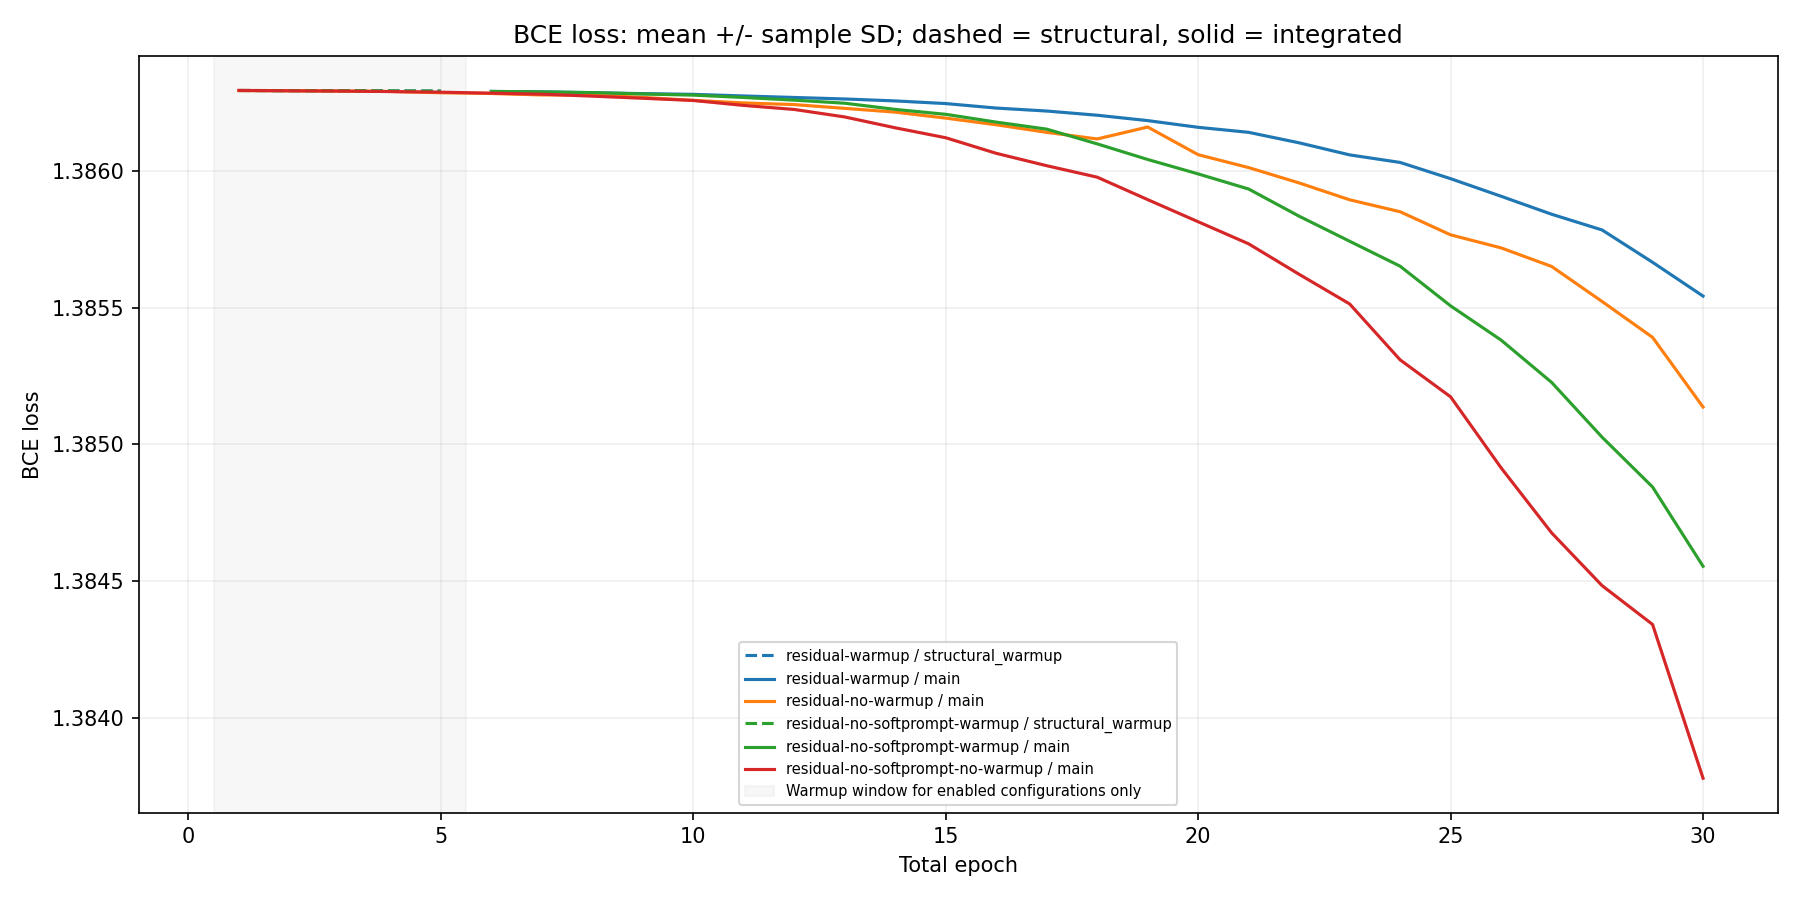

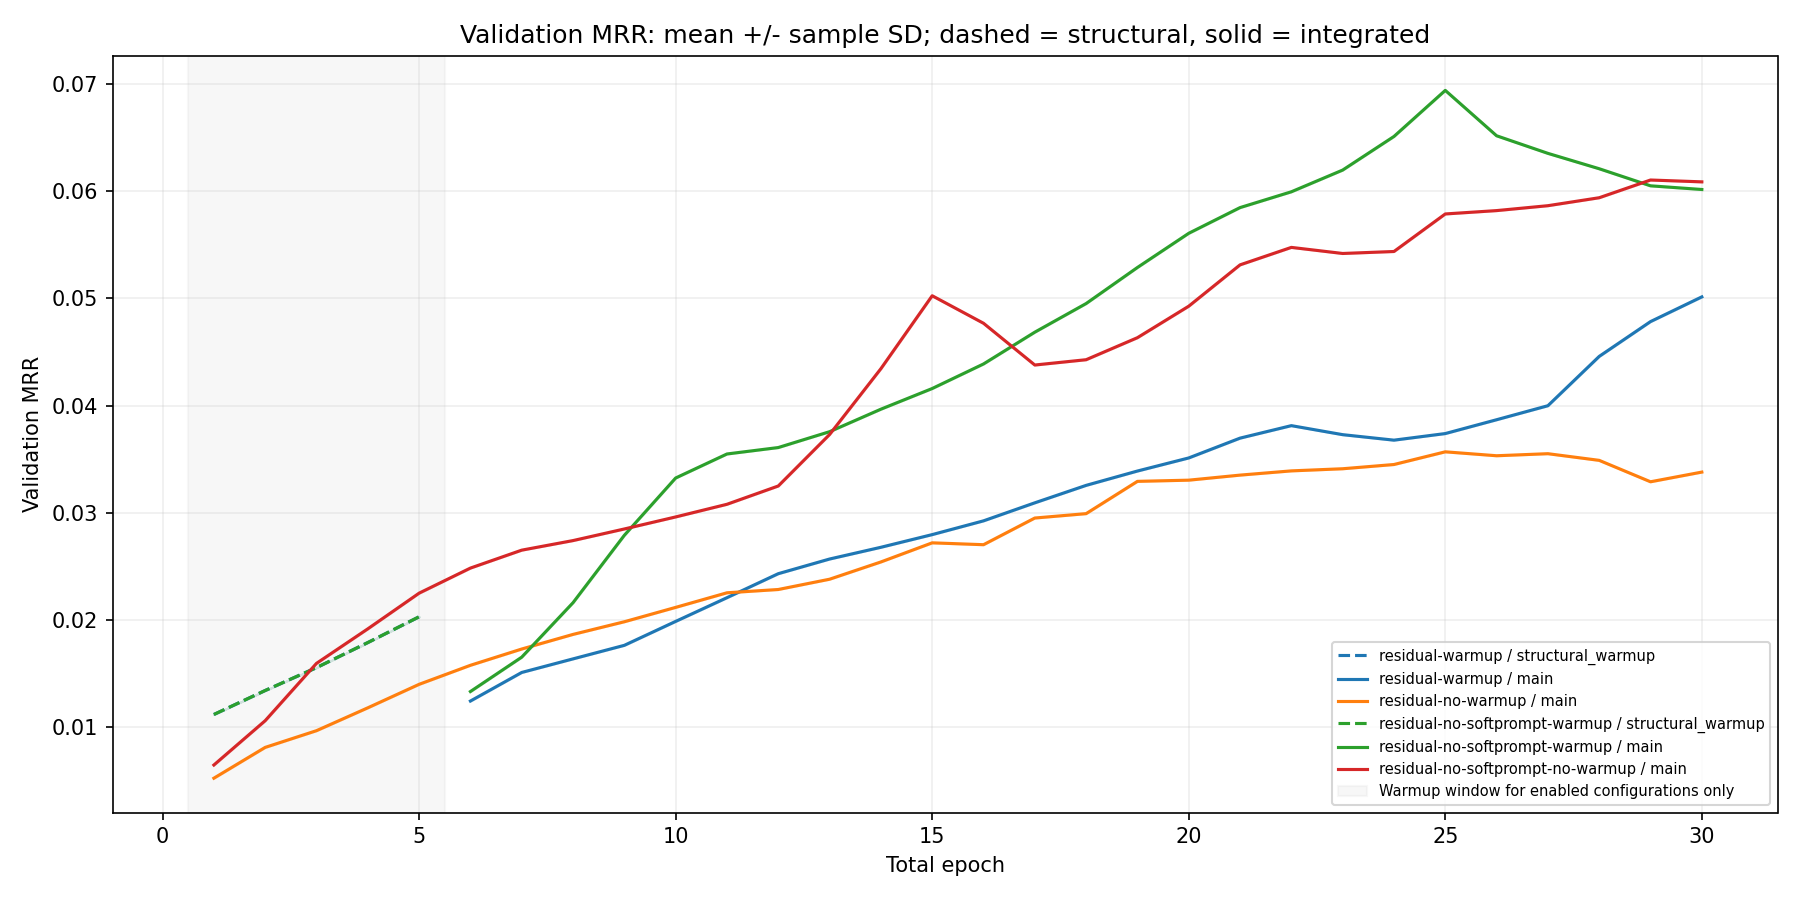

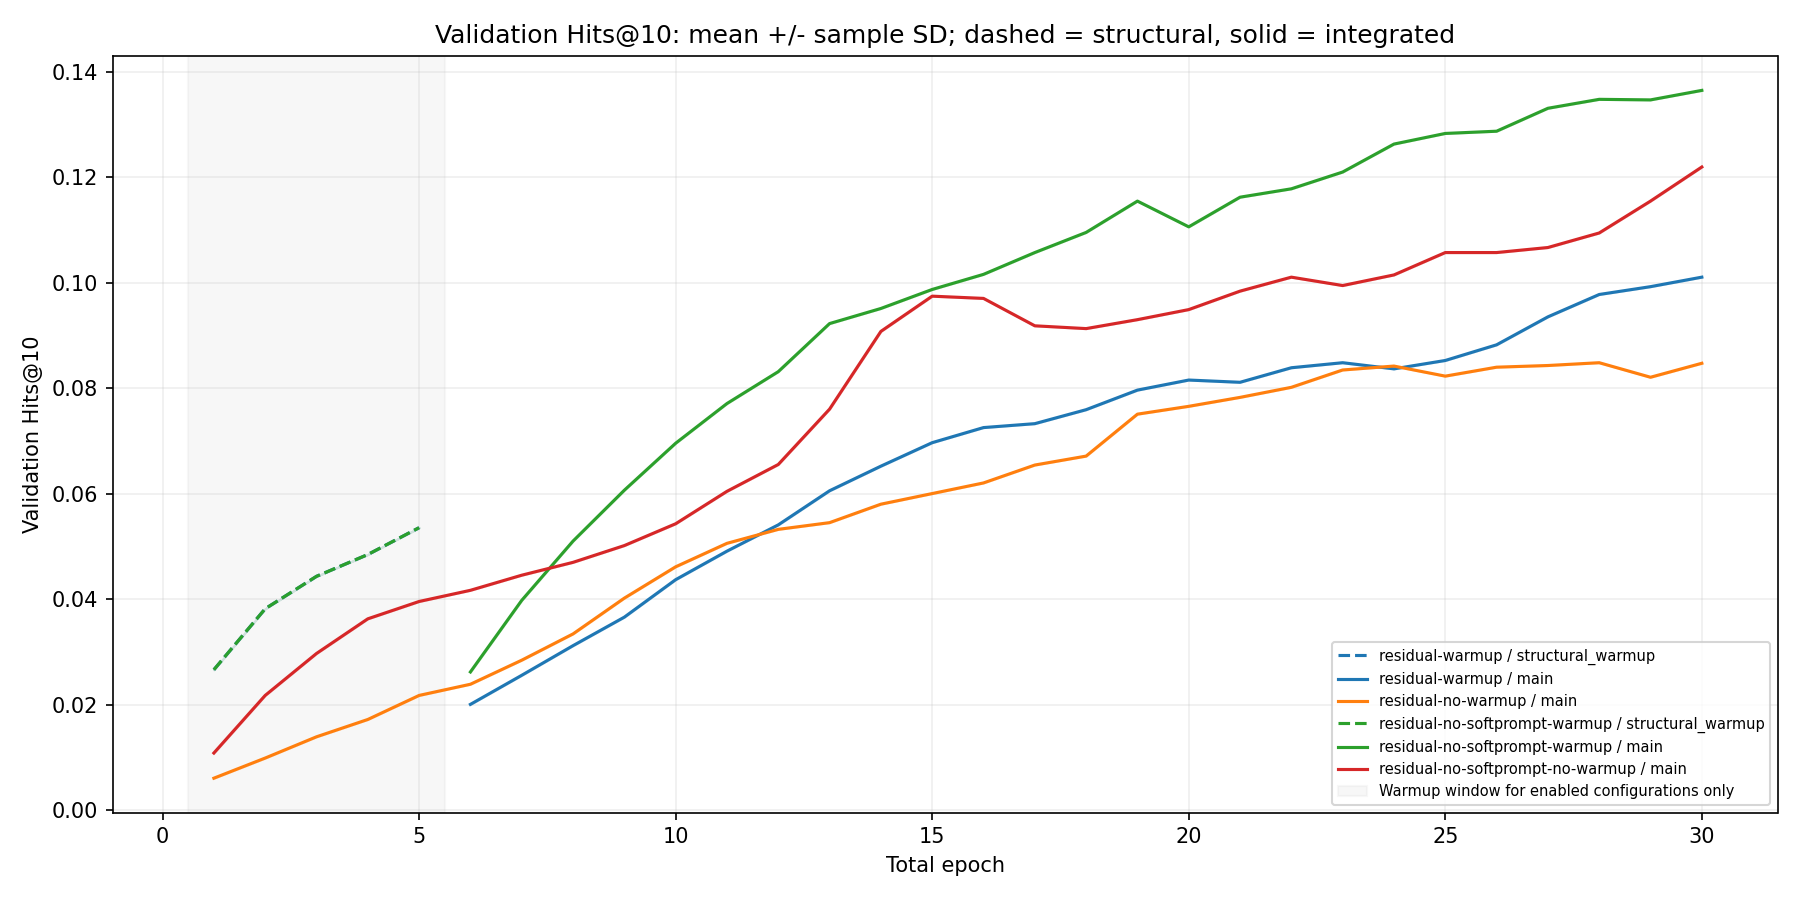

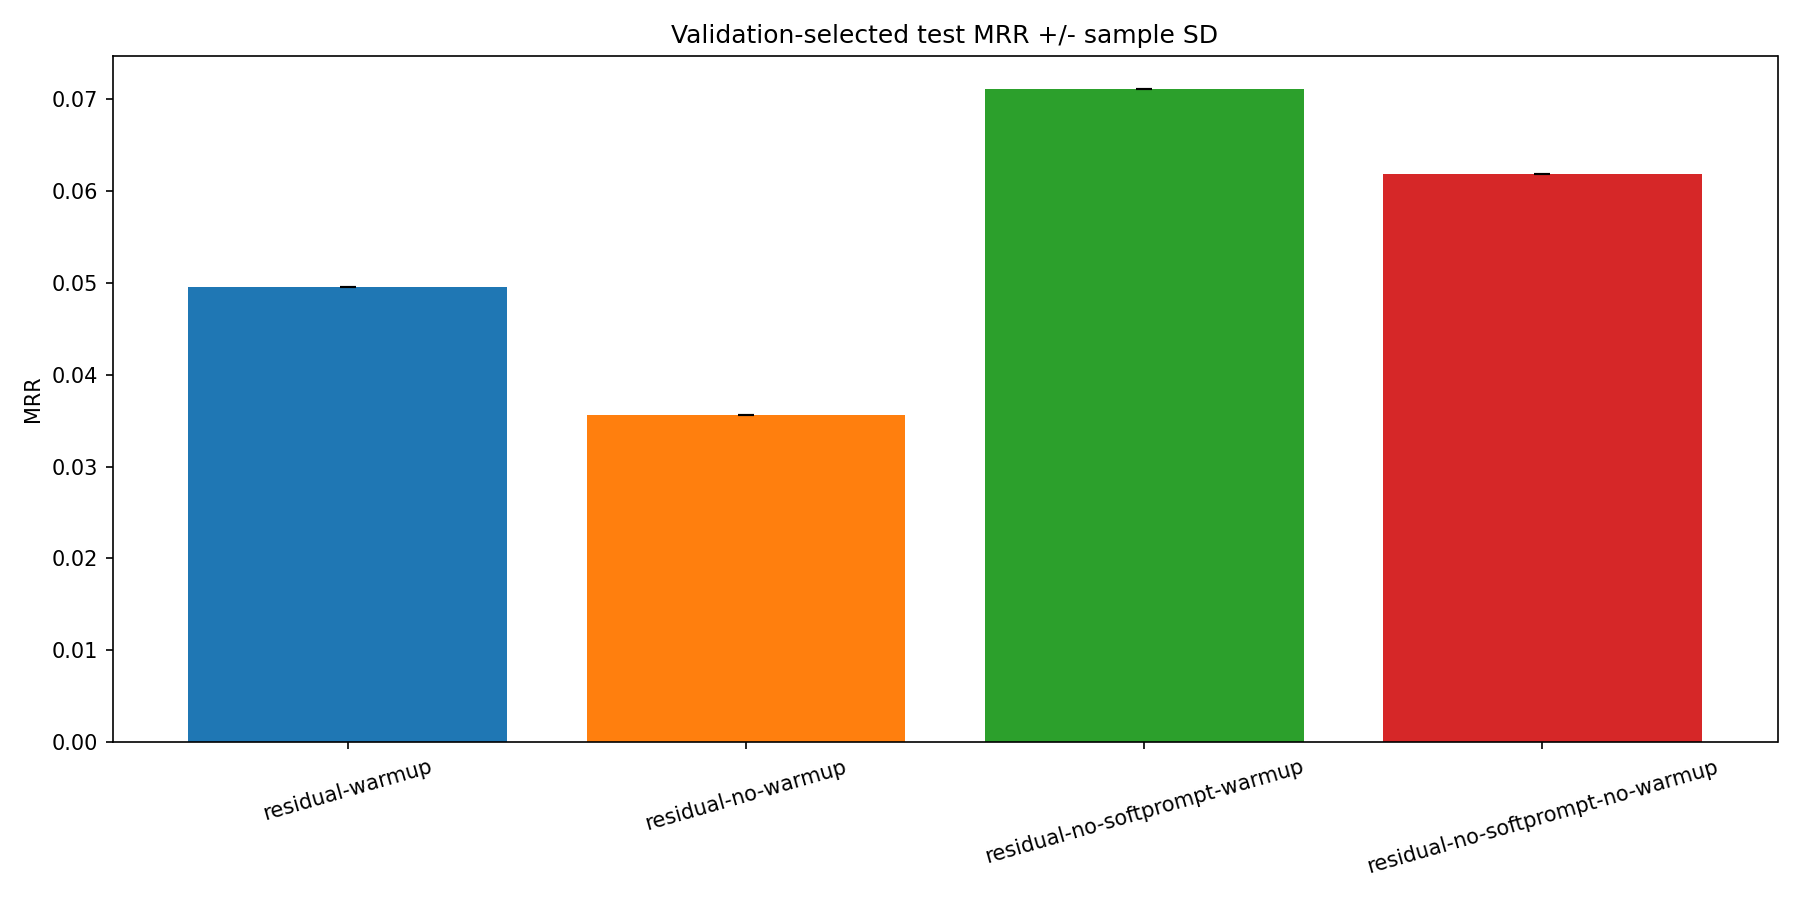

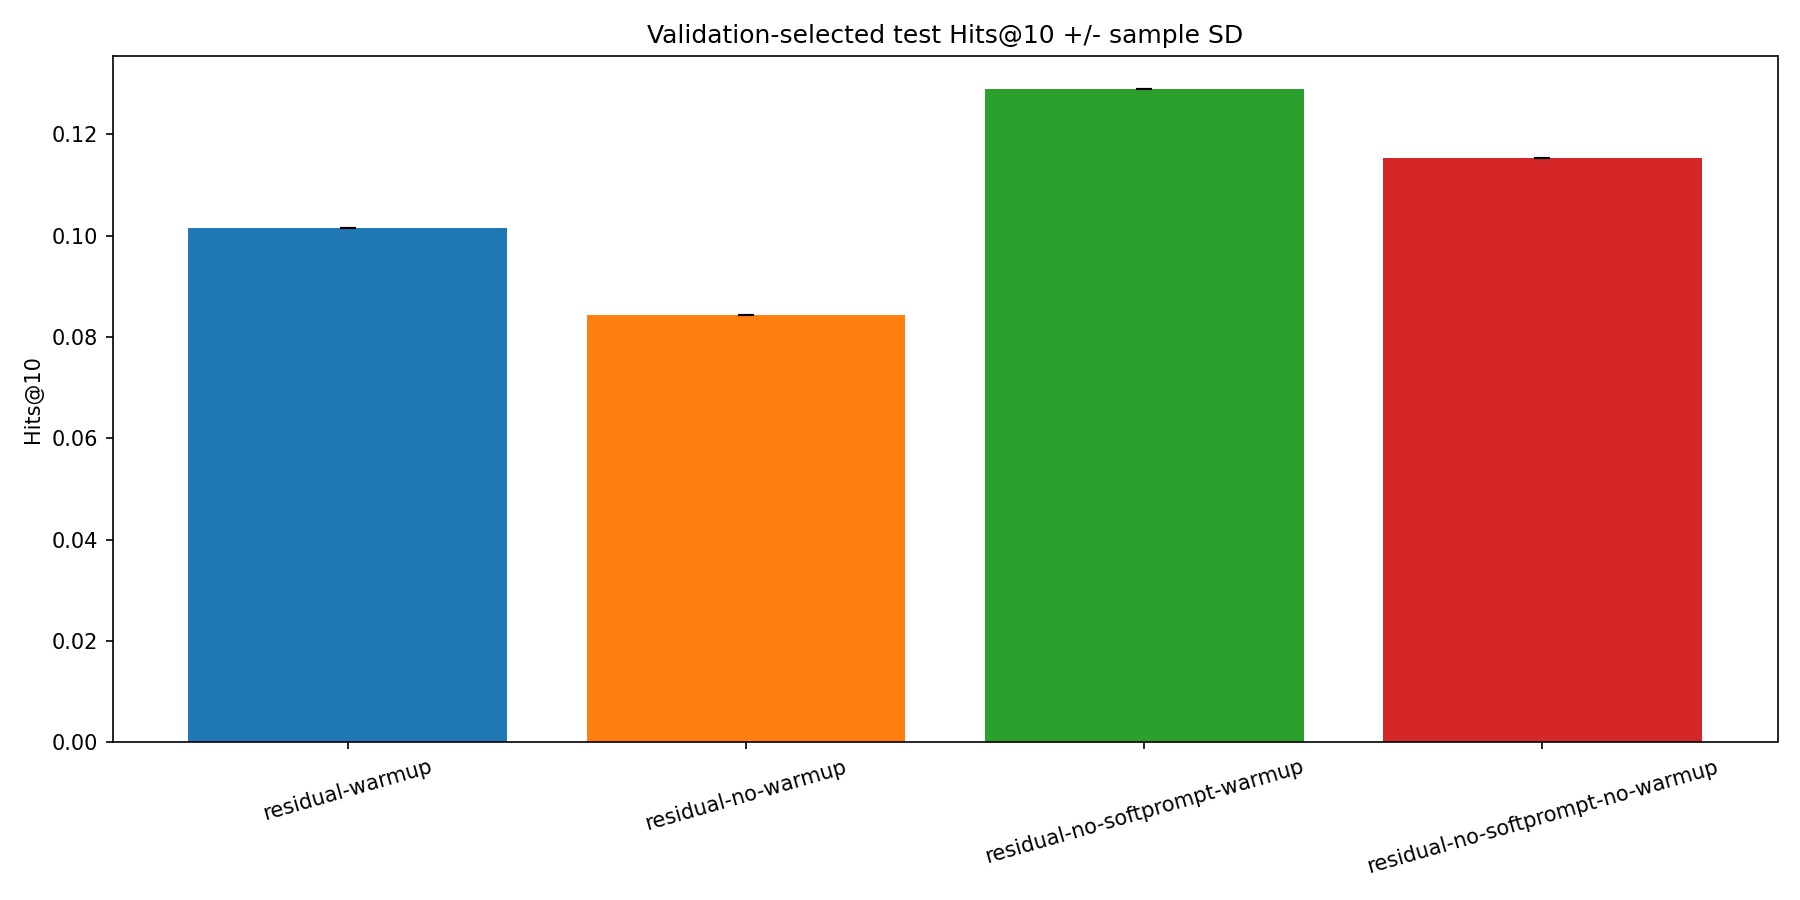

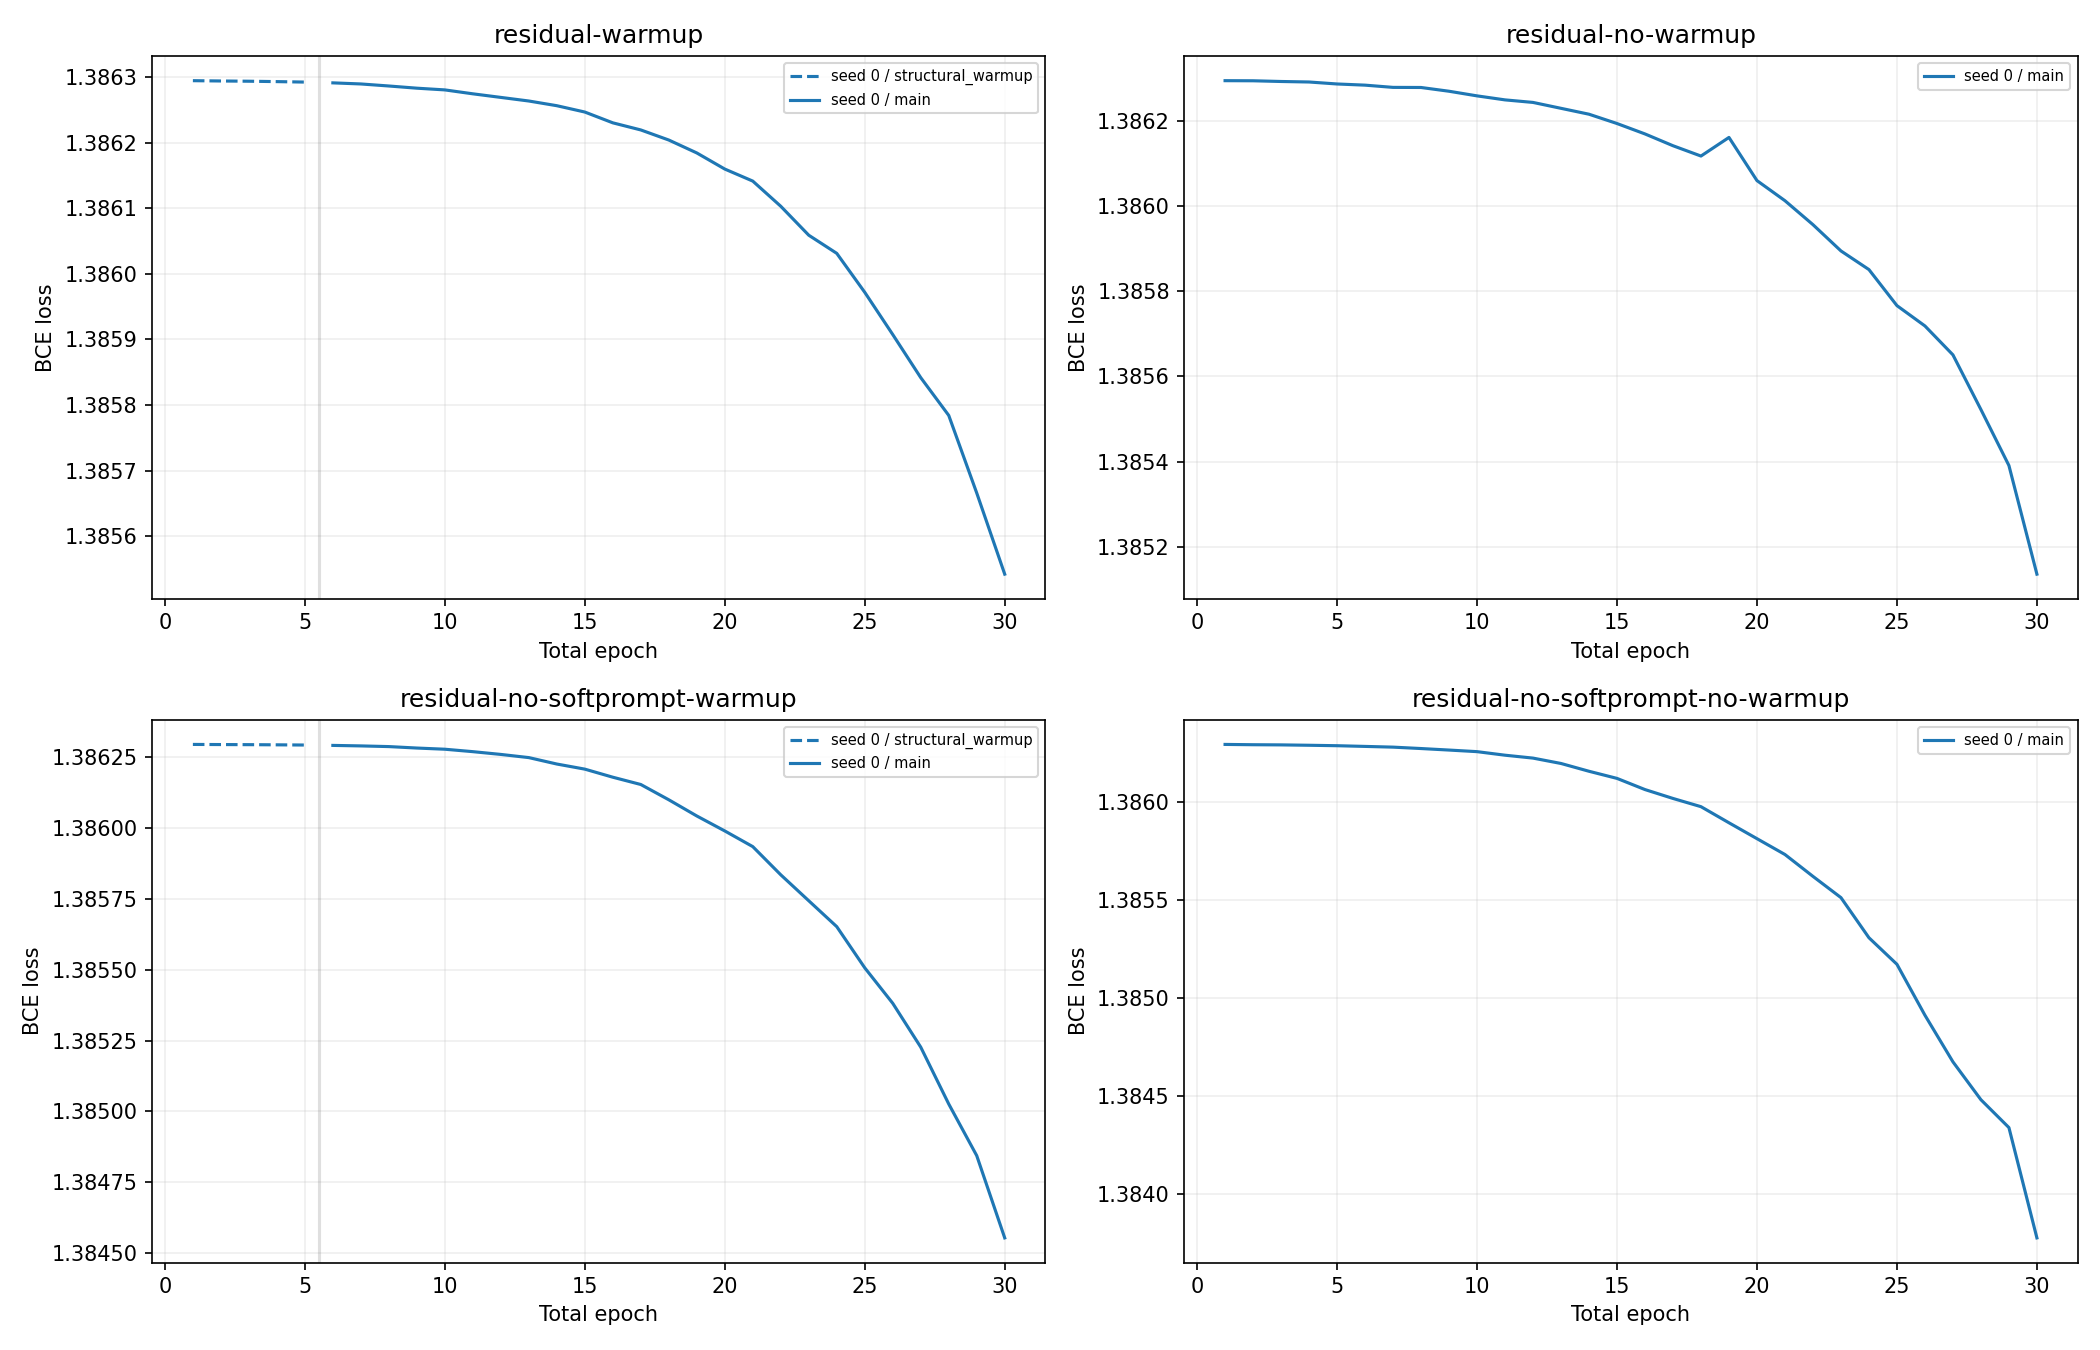

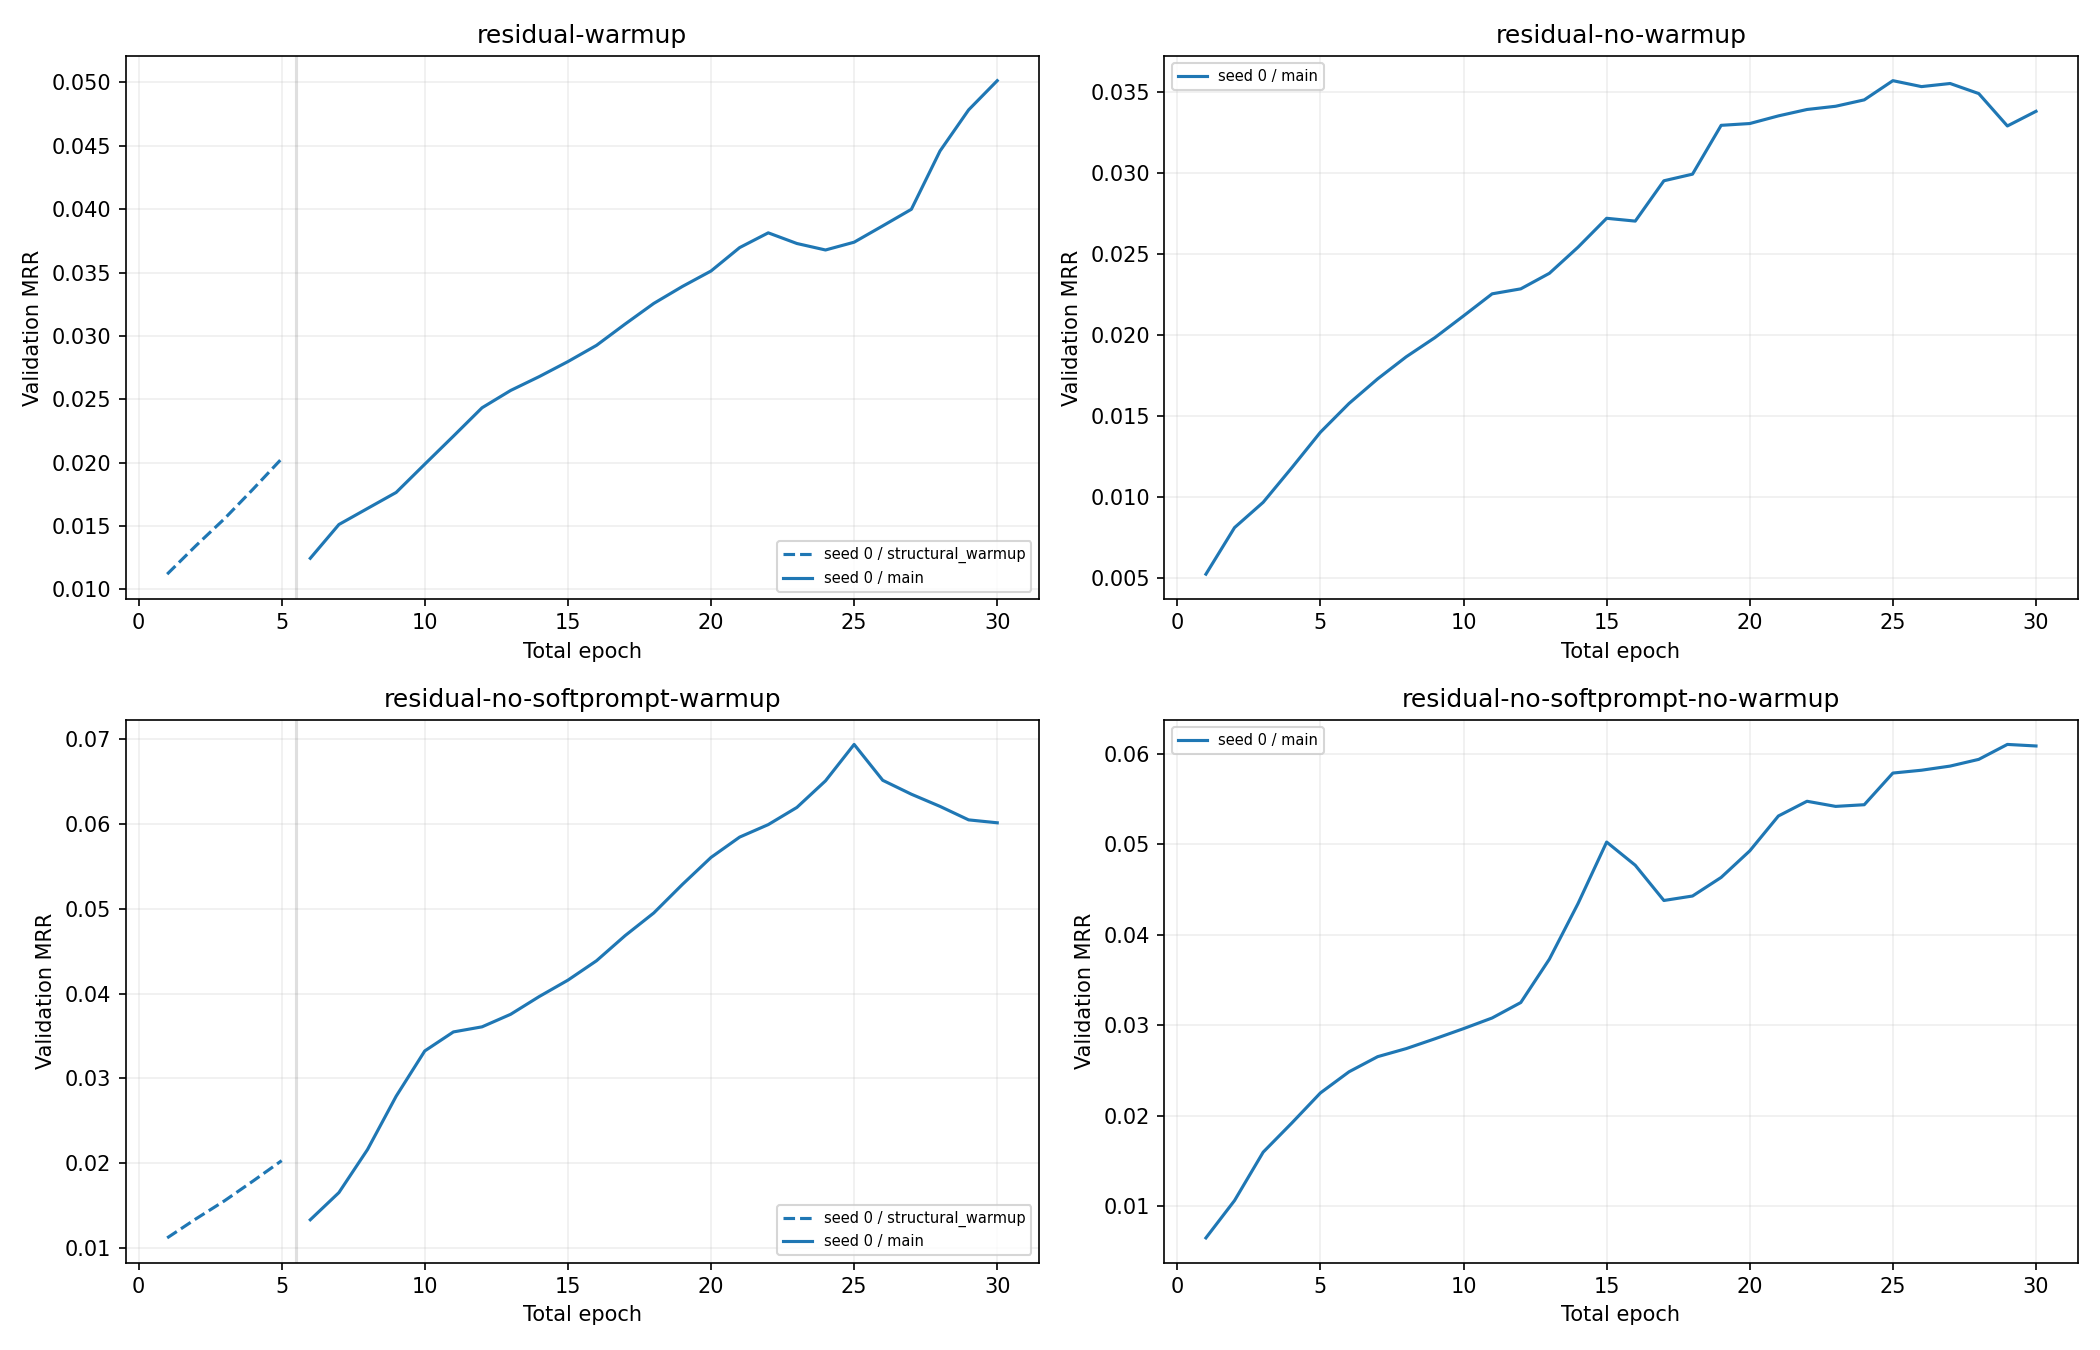

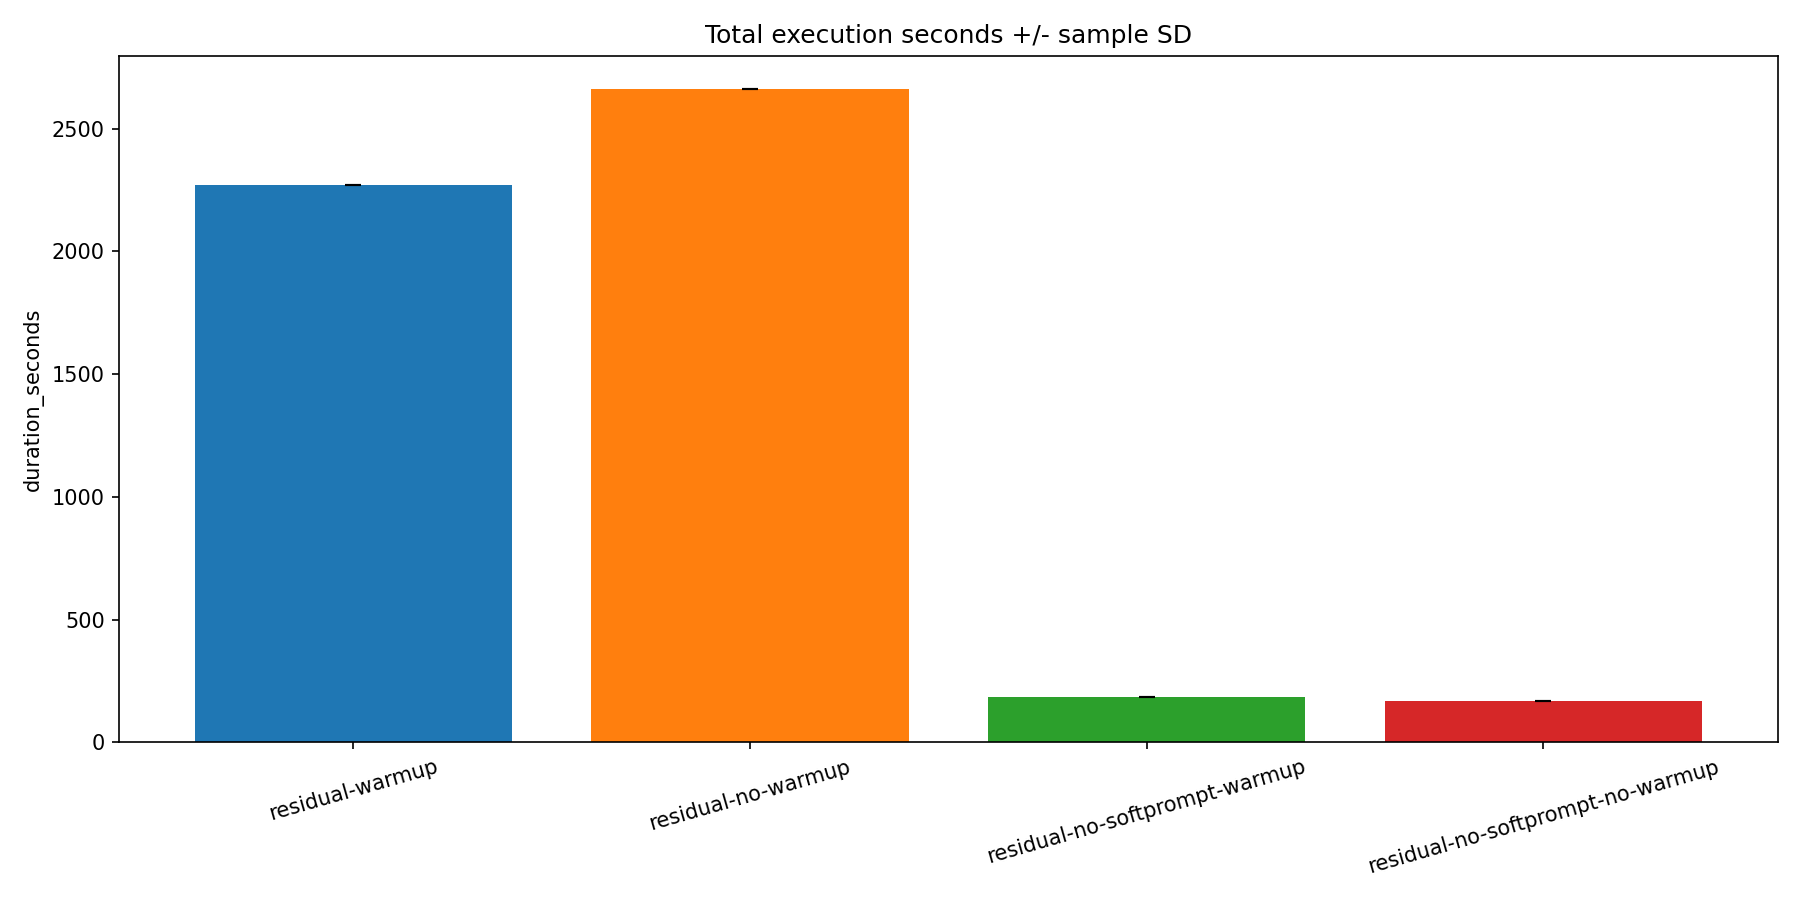

Reports, curves and all per-run artifacts: /content/drive/MyDrive/Research/warmup_ablation_5000/warmup5000_induced_v7_run1/runs
Diagnostic logs: /content/drive/MyDrive/Research/warmup_ablation_5000/warmup5000_induced_v7_run1/logs/20261010_125559_163924


In [64]:
from training.ablation_reports import PLOTS
summary_path = EXPERIMENT_DIR / 'summary.json'
if summary_path.exists():
    summary = json.loads(summary_path.read_text())
    display(pd.read_csv(EXPERIMENT_DIR / 'comparison.csv').sort_values('validation_MRR_mean', ascending=False))
    display(pd.read_csv(EXPERIMENT_DIR / 'runs.csv'))
    display(pd.DataFrame(summary['paired_comparisons']))
    display(pd.read_csv(EXPERIMENT_DIR / 'paired_seed_differences.csv'))
    print('Selected by validation:', summary['selected_by_validation'])
    print('Selected configuration test summary:', summary['selected_test_results'])
    behavior = json.loads((EXPERIMENT_DIR / 'training_behavior.json').read_text())
    display(pd.DataFrame(behavior))
    for row in behavior:
        if row['severe_tie_flags']:
            print('TIE WARNING:', row['configuration'], 'seed', row['seed'], row['severe_tie_flags'])
    display(pd.read_csv(EXPERIMENT_DIR / 'ties.csv'))
    for filename in PLOTS:
        display(Image(filename=str(EXPERIMENT_DIR / filename)))
else:
    print('No complete comparison yet. Finish all configured runs before interpreting a winner.')

with (RUN_ROOT / 'environment.txt').open('w') as stream:
    subprocess.run([sys.executable, '-m', 'pip', 'freeze'], stdout=stream, check=True)
print('Reports, curves and all per-run artifacts:', EXPERIMENT_DIR)
print('Diagnostic logs:', LOG_DIR)
